<a href="https://colab.research.google.com/github/eyluelo/eeg-mental-state-classification/blob/main/eeg_mental_state_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [5]:
import numpy
import pandas
import matplotlib


print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("matplotlib:", matplotlib.__version__)

numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0


In [11]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

print("kaggle credentials set")

kaggle credentials set


In [12]:
!kaggle datasets download -d birdy654/eeg-brainwave-dataset-mental-state

Dataset URL: https://www.kaggle.com/datasets/birdy654/eeg-brainwave-dataset-mental-state
License(s): other
100% 24.1M/24.1M [00:00<00:00, 101MB/s] 



In [15]:
import zipfile
with zipfile.ZipFile("eeg-brainwave-dataset-mental-state.zip", "r") as zip_ref:
  zip_ref.extractall("eeg_data")
print("zip file extracted")

zip file extracted


In [16]:
import os
os.listdir("eeg_data")

['mental-state.csv']

In [20]:
df = pandas.read_csv("eeg_data/mental-state.csv")
df.head()

,lag1_mean_0,lag1_mean_1,lag1_mean_2,lag1_mean_3,lag1_mean_d_h2h1_0,lag1_mean_d_h2h1_1,lag1_mean_d_h2h1_2,lag1_mean_d_h2h1_3,lag1_mean_q1_0,lag1_mean_q1_1,...,freq_669_3,freq_679_3,freq_689_3,freq_699_3,freq_709_3,freq_720_3,freq_730_3,freq_740_3,freq_750_3,Label
0,25.781648,33.836367,-92.769629,19.187957,-1.542262,0.197462,-119.561133,2.032654,21.596272,33.965587,...,0.000230,0.000351,0.000547,0.000381,0.000350,0.000453,0.000442,0.000325,0.000209,2.0
1,29.357891,26.792566,417.203910,19.472121,-38.797263,-16.897194,-29.368531,-9.055370,44.647424,40.893307,...,0.001671,0.000740,0.001122,0.000521,0.000624,0.000439,0.001249,0.000727,0.000801,2.0
2,28.451926,31.076434,72.231301,14.245938,-13.225057,-0.614138,-28.331698,-8.858742,31.450289,30.692883,...,0.000748,0.000569,0.000327,0.000197,0.000833,0.000909,0.000699,0.001165,0.000616,2.0
3,21.282184,19.985184,16.220094,39.787312,1.847866,0.670216,-1.820355,20.220724,21.404679,20.777411,...,0.000990,0.005644,0.006891,0.010546,0.009583,0.011158,0.008853,0.004551,0.002287,1.0
4,20.431516,28.982168,27.540246,19.960398,2.491458,-6.020503,-1.071166,2.655259,16.295039,32.658163,...,0.001659,0.014379,0.014492,0.002949,0.004575,0.008305,0.007202,0.006957,0.009836,2.0


In [54]:
print(df.shape)
df.describe()
print(df.columns)

print(df.columns[-1])
df['Label'].unique()
df['Label'].value_counts()

(2479, 989)
Index(['lag1_mean_0', 'lag1_mean_1', 'lag1_mean_2', 'lag1_mean_3',
       'lag1_mean_d_h2h1_0', 'lag1_mean_d_h2h1_1', 'lag1_mean_d_h2h1_2',
       'lag1_mean_d_h2h1_3', 'lag1_mean_q1_0', 'lag1_mean_q1_1',
       ...
       'freq_669_3', 'freq_679_3', 'freq_689_3', 'freq_699_3', 'freq_709_3',
       'freq_720_3', 'freq_730_3', 'freq_740_3', 'freq_750_3', 'Label'],
      dtype='object', length=989)
Label


,count
Label,
2.0,830
1.0,830
0.0,819


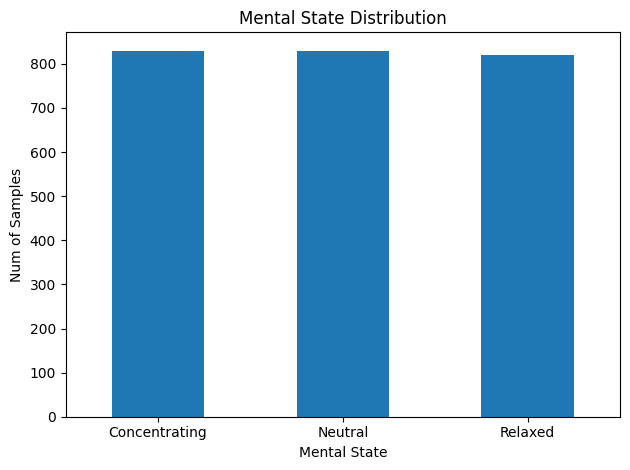

In [43]:
ax = df['Label'].value_counts().plot(kind='bar')

ax.set_title("Mental State Distribution")
ax.set_xlabel("Mental State")
ax.set_ylabel("Num of Samples")
ax.set_xticklabels(['Concentrating', 'Neutral', 'Relaxed'], rotation=0)

matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()


In [45]:
X = df.drop(columns=['Label'])
y = df['Label']

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size: ", X_train.shape)
print("Test size: ", X_test.shape)

Train size:  (1983, 988)
Test size:  (496, 988)


In [47]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Training complete.")

Training complete.


In [48]:
y_pred = model.predict(X_test)
print(y_pred[:10])
print(y_test[:10].values)

[1. 2. 0. 0. 2. 1. 0. 0. 1. 0.]
[1. 2. 0. 0. 2. 1. 0. 0. 1. 0.]


In [49]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.9616935483870968


In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Relaxed', 'Neutral', 'Concentrating']))

               precision    recall  f1-score   support

      Relaxed       1.00      0.96      0.98       167
      Neutral       0.96      0.93      0.95       167
Concentrating       0.93      1.00      0.96       162

     accuracy                           0.96       496
    macro avg       0.96      0.96      0.96       496
 weighted avg       0.96      0.96      0.96       496



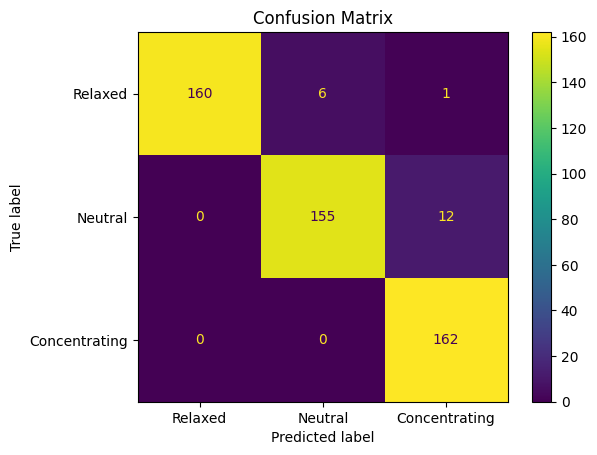

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Relaxed', 'Neutral', 'Concentrating'])
matplotlib.pyplot.title("Confusion Matrix")
matplotlib.pyplot.show()